## Array Imaging Investigation

Import libraries

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

Initialise and configure devices

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.230 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [70]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## Generate Initial Array Hologram

In [71]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

In [72]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.33e-05 | Uniformity: 55.14% | Min/Max ratio: 0.131
Iteration 010 | Mean-Squared Error: 1.82e-07 | Uniformity: 81.92% | Min/Max ratio: 0.476
Iteration 020 | Mean-Squared Error: 9.59e-09 | Uniformity: 83.52% | Min/Max ratio: 0.535
Iteration 030 | Mean-Squared Error: 1.86e-09 | Uniformity: 83.58% | Min/Max ratio: 0.526
Iteration 040 | Mean-Squared Error: 1.22e-09 | Uniformity: 83.58% | Min/Max ratio: 0.526
Iteration 050 | Mean-Squared Error: 2.57e-09 | Uniformity: 83.57% | Min/Max ratio: 0.528
Iteration 060 | Mean-Squared Error: 2.84e-09 | Uniformity: 83.55% | Min/Max ratio: 0.533
Iteration 070 | Mean-Squared Error: 3.09e-09 | Uniformity: 83.53% | Min/Max ratio: 0.528
Iteration 080 | Mean-Squared Error: 4.87e-09 | Uniformity: 83.63% | Min/Max ratio: 0.528
Iteration 090 | Mean-Squared Error: 8.00e-09 | Uniformity: 83.61% | Min/Max ratio: 0.526
Itera

Load initial array onto the SLM

In [73]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Load and Image Initial Array


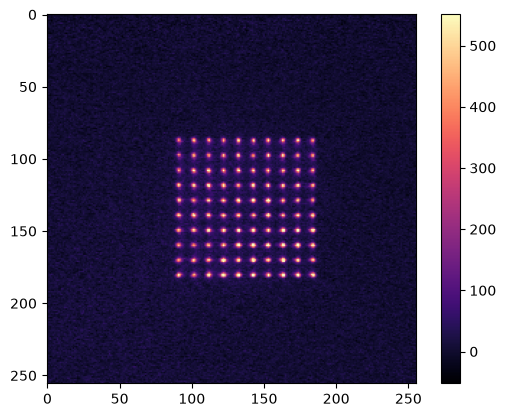

In [75]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


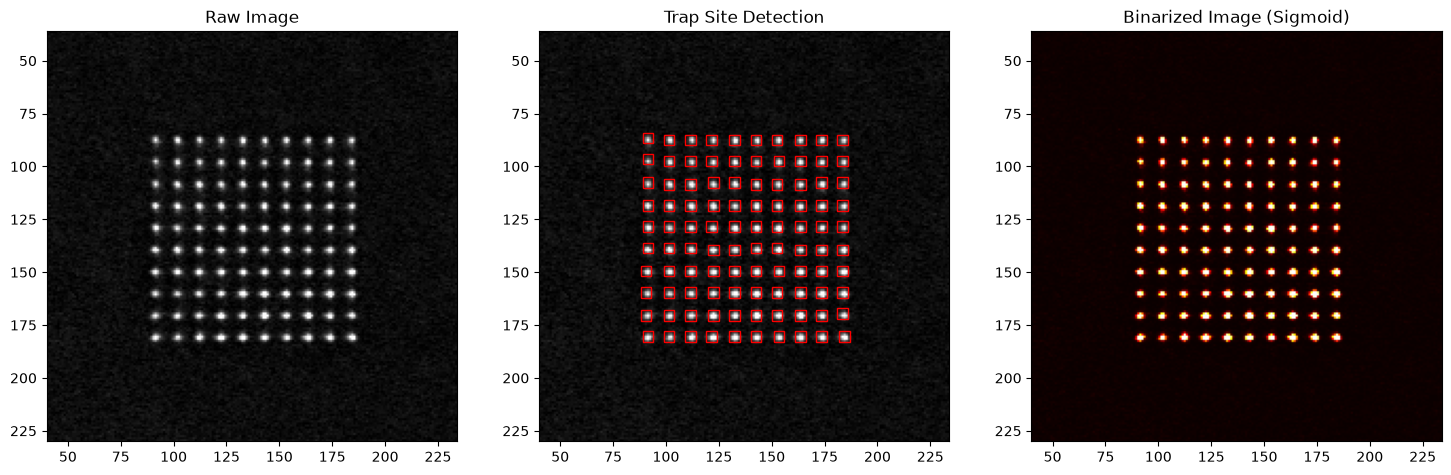

Trap (0, 0) Loading Probability : 45.00 %
Trap (0, 1) Loading Probability : 49.00 %
Trap (0, 2) Loading Probability : 44.00 %
Trap (0, 3) Loading Probability : 47.00 %
Trap (0, 4) Loading Probability : 52.00 %
Trap (0, 5) Loading Probability : 43.00 %
Trap (0, 6) Loading Probability : 44.00 %
Trap (0, 7) Loading Probability : 47.00 %
Trap (0, 8) Loading Probability : 49.00 %
Trap (0, 9) Loading Probability : 50.00 %
Trap (1, 0) Loading Probability : 40.00 %
Trap (1, 1) Loading Probability : 43.00 %
Trap (1, 2) Loading Probability : 44.00 %
Trap (1, 3) Loading Probability : 40.00 %
Trap (1, 4) Loading Probability : 46.00 %
Trap (1, 5) Loading Probability : 36.00 %
Trap (1, 6) Loading Probability : 50.00 %
Trap (1, 7) Loading Probability : 48.00 %
Trap (1, 8) Loading Probability : 43.00 %
Trap (1, 9) Loading Probability : 42.00 %
Trap (2, 0) Loading Probability : 40.00 %
Trap (2, 1) Loading Probability : 51.00 %
Trap (2, 2) Loading Probability : 51.00 %
Trap (2, 3) Loading Probability : 

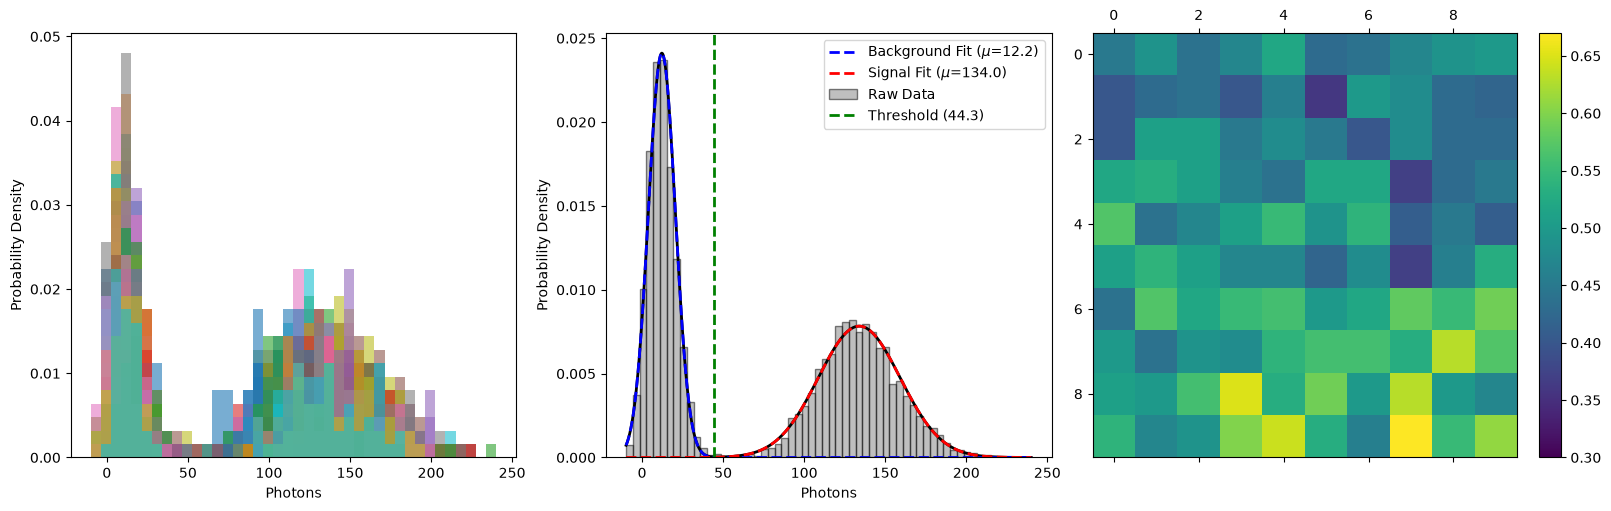

In [76]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

## Routine MOT Shim Coil Optimisation

In [23]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer

In [24]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=0.5),
    Real(name='tMOTShimYccValue', low=-5.0, high=0.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=0.0)
]

# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMOTLoadingDuration": 10000, "PatternLength": 30000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, _ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=False, threshold=threshold_1, binning=60, show_histogram=False, verbose=False)    
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [25]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 50
n_initial_points = 10
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
Parameters: tMOTShimXccValue = 0.06, tMOTShimYccValue = -4.63, tMOTShimZccValue = -0.39  |  Mean Loading Probability = 0.0630
Iteration 1/50 (xi = 0.1000)
  Current score: 0.0630
  Best score: 0.0630

Parameters: tMOTShimXccValue = 0.01, tMOTShimYccValue = -4.24, tMOTShimZccValue = -0.05  |  Mean Loading Probability = 0.0030
Iteration 2/50 (xi = 0.0980)
  Current score: 0.0030
  Best score: 0.0630

Parameters: tMOTShimXccValue = 0.40, tMOTShimYccValue = -3.78, tMOTShimZccValue = -0.67  |  Mean Loading Probability = 0.1596
Iteration 3/50 (xi = 0.0960)
  Current score: 0.1596
  Best score: 0.1596

Parameters: tMOTShimXccValue = 0.22, tMOTShimYccValue = -4.33, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.0618
Iteration 4/50 (xi = 0.0939)
  Current score: 0.0618
  Best score: 0.1596

Parameters: tMOTShimXccValue = 0.49, tMOTShimYccValue = -4.56, tMOTShimZccValue = -0.71  |  Mean Loading Probability = 0.1094
Iteration 5

In [26]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.001580451214173662.
Parameter 'tMOTShimYccValue' set to -0.013713456426662773.
Parameter 'tMOTShimZccValue' set to -0.6434355744338989.
Parameters saved.


## Baseline Survival Probability

In [47]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
photons_2, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_2, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

Baseline survival probability: 0.9837


Trap (0, 0) Loading Probability : 55.00 %
Trap (0, 1) Loading Probability : 48.00 %
Trap (0, 2) Loading Probability : 51.00 %
Trap (0, 3) Loading Probability : 59.00 %
Trap (0, 4) Loading Probability : 58.00 %
Trap (0, 5) Loading Probability : 50.00 %
Trap (0, 6) Loading Probability : 53.50 %
Trap (0, 7) Loading Probability : 52.50 %
Trap (0, 8) Loading Probability : 50.00 %
Trap (0, 9) Loading Probability : 53.50 %
Trap (1, 0) Loading Probability : 53.00 %
Trap (1, 1) Loading Probability : 56.50 %
Trap (1, 2) Loading Probability : 55.00 %
Trap (1, 3) Loading Probability : 53.00 %
Trap (1, 4) Loading Probability : 53.00 %
Trap (1, 5) Loading Probability : 59.50 %
Trap (1, 6) Loading Probability : 48.00 %
Trap (1, 7) Loading Probability : 52.50 %
Trap (1, 8) Loading Probability : 52.50 %
Trap (1, 9) Loading Probability : 48.50 %
Trap (2, 0) Loading Probability : 57.00 %
Trap (2, 1) Loading Probability : 57.00 %
Trap (2, 2) Loading Probability : 59.50 %
Trap (2, 3) Loading Probability : 

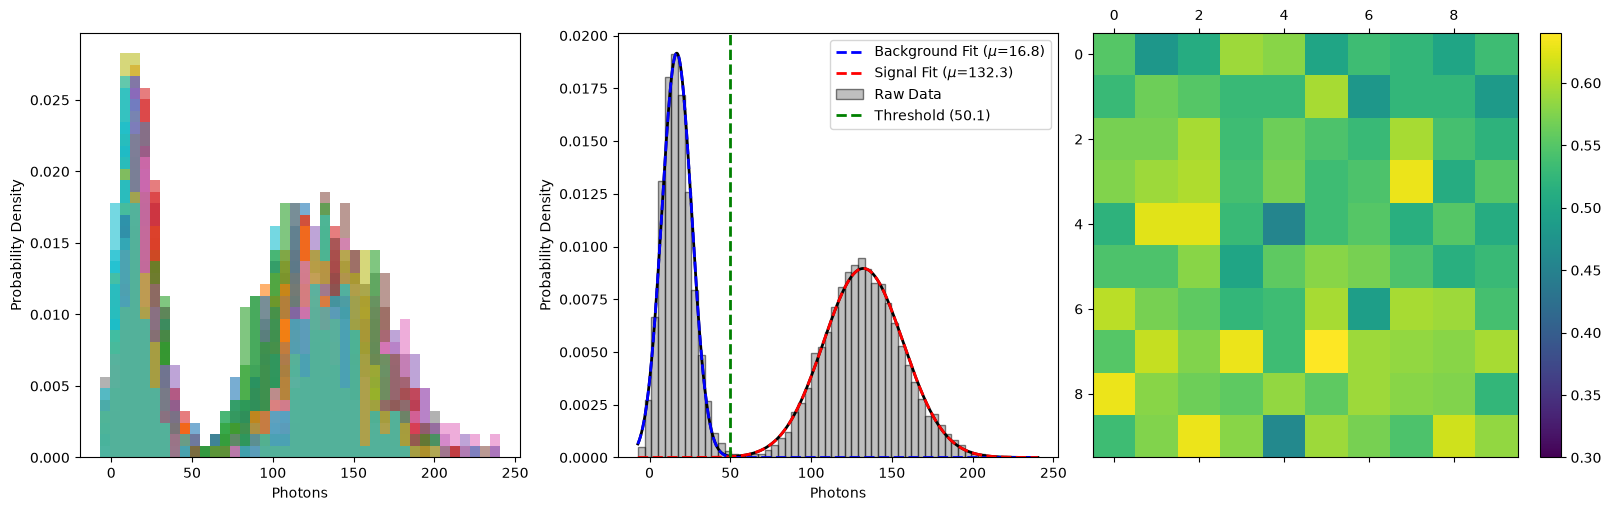

In [48]:
photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=True, verbose=True)

---
## Imaging VCO Scan

In [37]:
# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

vco_list = np.linspace(0.0, 4.5, 30)
surv_list, loading_list, fidelity_list = [], [], []

for vco in vco_list:
    ExpParams.set_parameter("tImgCoolVCO", vco)
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape, window_size=window)
    mean_loading_probability = np.mean(loading_probabilities)

    surv_list.append(survival_probability)
    loading_list.append(mean_loading_probability)
    fidelity_list.append(fidelity)

    print(f"Cooling VCO: {vco:.3f} V, Mean Loading Probability: {mean_loading_probability*100:.4f} %, Survival Probability: {survival_probability*100:.4f} %, Detection Fidelity: {fidelity*100:.4f} %")

Parameter 'tImgCoolVCO' set to 0.0.
Cooling VCO: 0.000 V, Mean Loading Probability: 44.5600 %, Survival Probability: 60.3038 %, Detection Fidelity: 81.9111 %
Parameter 'tImgCoolVCO' set to 0.15517241379310345.
Cooling VCO: 0.155 V, Mean Loading Probability: 46.5200 %, Survival Probability: 64.3166 %, Detection Fidelity: 82.8248 %
Parameter 'tImgCoolVCO' set to 0.3103448275862069.
Cooling VCO: 0.310 V, Mean Loading Probability: 46.2400 %, Survival Probability: 65.4935 %, Detection Fidelity: 84.7813 %
Parameter 'tImgCoolVCO' set to 0.4655172413793104.
Cooling VCO: 0.466 V, Mean Loading Probability: 47.7400 %, Survival Probability: 69.9836 %, Detection Fidelity: 84.6740 %
Parameter 'tImgCoolVCO' set to 0.6206896551724138.
Cooling VCO: 0.621 V, Mean Loading Probability: 50.4800 %, Survival Probability: 71.8607 %, Detection Fidelity: 85.6338 %
Parameter 'tImgCoolVCO' set to 0.7758620689655172.
Cooling VCO: 0.776 V, Mean Loading Probability: 50.3200 %, Survival Probability: 74.6732 %, Detect

Optimal Cooling VCO: 2.948 V, Survival Probability: 97.7165 %, Loading Probability: 55.8200 %, Detection Fidelity: 99.6380 %
Parameter 'tImgCoolVCO' set to 2.9482758620689657.


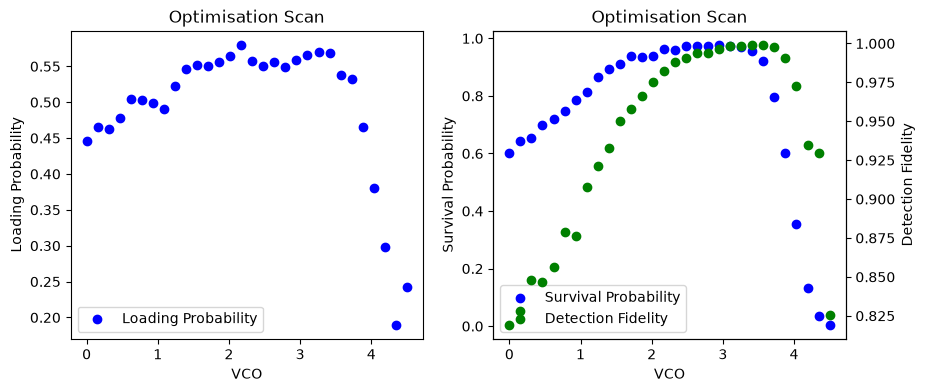

In [38]:
# Plot the loading probability vs vco in one plot and in a second plot plot the survival probability and detection fidelity vs vco in the same plot with different y axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(vco_list, loading_list, label="Loading Probability", color="blue")
ax1.set_xlabel("VCO")
ax1.set_ylabel("Loading Probability")
ax1.set_title("Optimisation Scan")
ax1.legend()

# Create a second y-axis for the right plot
ax2_right = ax2.twinx()
ax2.scatter(vco_list, surv_list, label="Survival Probability", color="blue")
ax2_right.scatter(vco_list, fidelity_list, label="Detection Fidelity", color="green")

# Set labels and titles
ax2.set_xlabel("VCO")
ax2.set_ylabel("Survival Probability")
ax2_right.set_ylabel("Detection Fidelity")
ax2.set_title("Optimisation Scan")

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

max_index = np.argmax(surv_list)

print(f"Optimal Cooling VCO: {vco_list[max_index]:.3f} V, Survival Probability: {surv_list[max_index]*100:.4f} %, Loading Probability: {loading_list[max_index]*100:.4f} %, Detection Fidelity: {fidelity_list[max_index]*100:.4f} %")

ExpParams.set_parameter("tImgCoolVCO", vco_list[max_index])

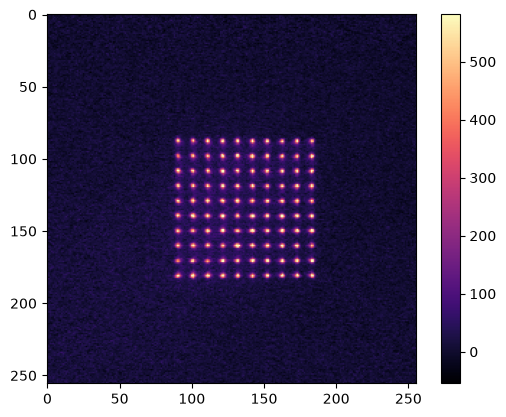

In [39]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


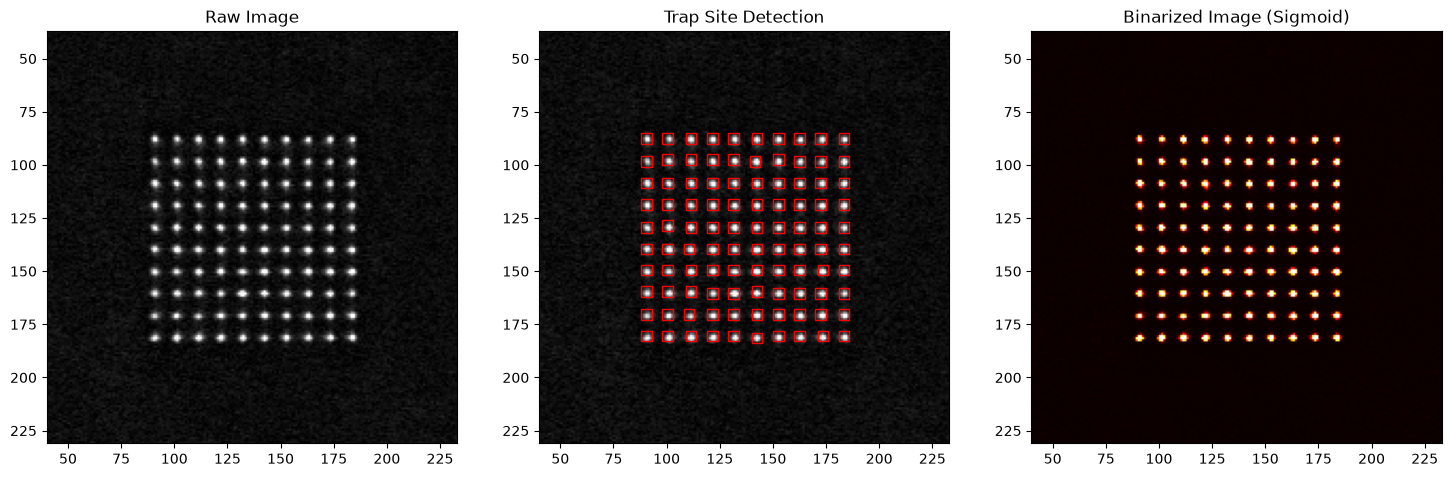

Trap (0, 0) Loading Probability : 59.00 %
Trap (0, 1) Loading Probability : 53.00 %
Trap (0, 2) Loading Probability : 57.00 %
Trap (0, 3) Loading Probability : 61.00 %
Trap (0, 4) Loading Probability : 53.00 %
Trap (0, 5) Loading Probability : 59.00 %
Trap (0, 6) Loading Probability : 55.00 %
Trap (0, 7) Loading Probability : 50.00 %
Trap (0, 8) Loading Probability : 57.00 %
Trap (0, 9) Loading Probability : 56.00 %
Trap (1, 0) Loading Probability : 49.00 %
Trap (1, 1) Loading Probability : 51.00 %
Trap (1, 2) Loading Probability : 55.00 %
Trap (1, 3) Loading Probability : 57.00 %
Trap (1, 4) Loading Probability : 60.00 %
Trap (1, 5) Loading Probability : 60.00 %
Trap (1, 6) Loading Probability : 57.00 %
Trap (1, 7) Loading Probability : 51.00 %
Trap (1, 8) Loading Probability : 57.00 %
Trap (1, 9) Loading Probability : 59.00 %
Trap (2, 0) Loading Probability : 63.00 %
Trap (2, 1) Loading Probability : 62.00 %
Trap (2, 2) Loading Probability : 50.00 %
Trap (2, 3) Loading Probability : 

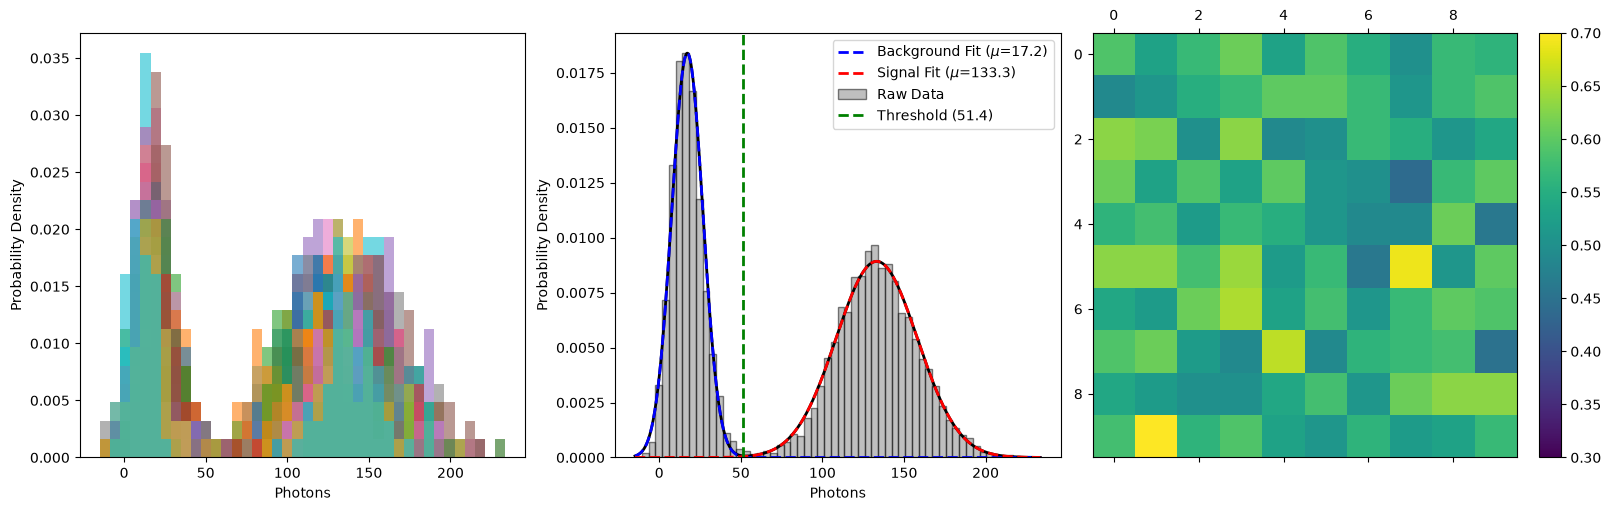

In [40]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

---
## Imaging VVA Scan

In [50]:
# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

vva_list = np.linspace(1.0, 1.5, 15)
surv_list, loading_list, fidelity_list = [], [], []

for vva in vva_list:
    ExpParams.set_parameter("tImgCoolVVA", vva)
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape, window_size=window)
    mean_loading_probability = np.mean(loading_probabilities)

    surv_list.append(survival_probability)
    loading_list.append(mean_loading_probability)
    fidelity_list.append(fidelity)

    print(f"Cooling VVA: {vva:.3f} V, Mean Loading Probability: {mean_loading_probability*100:.4f} %, Survival Probability: {survival_probability*100:.4f} %, Detection Fidelity: {fidelity*100:.4f} %")

Parameter 'tImgCoolVVA' set to 1.0.
Cooling VVA: 1.000 V, Mean Loading Probability: 55.4000 %, Survival Probability: 98.7173 %, Detection Fidelity: 99.9663 %
Parameter 'tImgCoolVVA' set to 1.0357142857142858.
Cooling VVA: 1.036 V, Mean Loading Probability: 55.1400 %, Survival Probability: 98.5353 %, Detection Fidelity: 99.9636 %
Parameter 'tImgCoolVVA' set to 1.0714285714285714.
Cooling VVA: 1.071 V, Mean Loading Probability: 55.9400 %, Survival Probability: 98.4340 %, Detection Fidelity: 99.9650 %
Parameter 'tImgCoolVVA' set to 1.1071428571428572.
Cooling VVA: 1.107 V, Mean Loading Probability: 56.1400 %, Survival Probability: 98.3051 %, Detection Fidelity: 99.9719 %
Parameter 'tImgCoolVVA' set to 1.1428571428571428.
Cooling VVA: 1.143 V, Mean Loading Probability: 54.8000 %, Survival Probability: 98.0907 %, Detection Fidelity: 99.9640 %
Parameter 'tImgCoolVVA' set to 1.1785714285714286.
Cooling VVA: 1.179 V, Mean Loading Probability: 54.8200 %, Survival Probability: 98.6915 %, Detecti

Optimal Cooling VVA: 1.000 V, Survival Probability: 98.7173 %, Loading Probability: 55.4000 %, Detection Fidelity: 99.9663 %
Parameter 'tImgCoolVVA' set to 1.0.


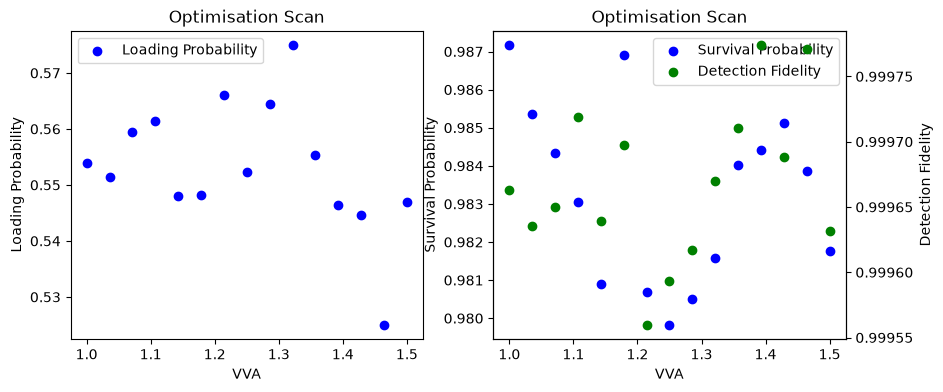

In [51]:
# Plot the loading probability vs vco in one plot and in a second plot plot the survival probability and detection fidelity vs vco in the same plot with different y axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(vva_list, loading_list, label="Loading Probability", color="blue")
ax1.set_xlabel("VVA")
ax1.set_ylabel("Loading Probability")
ax1.set_title("Optimisation Scan")
ax1.legend()

# Create a second y-axis for the right plot
ax2_right = ax2.twinx()
ax2.scatter(vva_list, surv_list, label="Survival Probability", color="blue")
ax2_right.scatter(vva_list, fidelity_list, label="Detection Fidelity", color="green")

# Set labels and titles
ax2.set_xlabel("VVA")
ax2.set_ylabel("Survival Probability")
ax2_right.set_ylabel("Detection Fidelity")
ax2.set_title("Optimisation Scan")

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

max_index = np.argmax(surv_list)

print(f"Optimal Cooling VVA: {vva_list[max_index]:.3f} V, Survival Probability: {surv_list[max_index]*100:.4f} %, Loading Probability: {loading_list[max_index]*100:.4f} %, Detection Fidelity: {fidelity_list[max_index]*100:.4f} %")

ExpParams.set_parameter("tImgCoolVVA", vva_list[max_index])

## Verification

In [65]:
# Experiment and camera setup
n_iterations = 500
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
photons_2, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_2, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

Baseline survival probability: 0.9844


Trap (0, 0) Loading Probability : 56.80 %
Trap (0, 1) Loading Probability : 51.80 %
Trap (0, 2) Loading Probability : 52.80 %
Trap (0, 3) Loading Probability : 54.20 %
Trap (0, 4) Loading Probability : 54.60 %
Trap (0, 5) Loading Probability : 57.60 %
Trap (0, 6) Loading Probability : 59.60 %
Trap (0, 7) Loading Probability : 55.40 %
Trap (0, 8) Loading Probability : 51.80 %
Trap (0, 9) Loading Probability : 54.40 %
Trap (1, 0) Loading Probability : 52.80 %
Trap (1, 1) Loading Probability : 63.00 %
Trap (1, 2) Loading Probability : 53.20 %
Trap (1, 3) Loading Probability : 55.20 %
Trap (1, 4) Loading Probability : 58.00 %
Trap (1, 5) Loading Probability : 56.80 %
Trap (1, 6) Loading Probability : 54.20 %
Trap (1, 7) Loading Probability : 57.20 %
Trap (1, 8) Loading Probability : 53.40 %
Trap (1, 9) Loading Probability : 55.60 %
Trap (2, 0) Loading Probability : 54.40 %
Trap (2, 1) Loading Probability : 52.60 %
Trap (2, 2) Loading Probability : 54.20 %
Trap (2, 3) Loading Probability : 

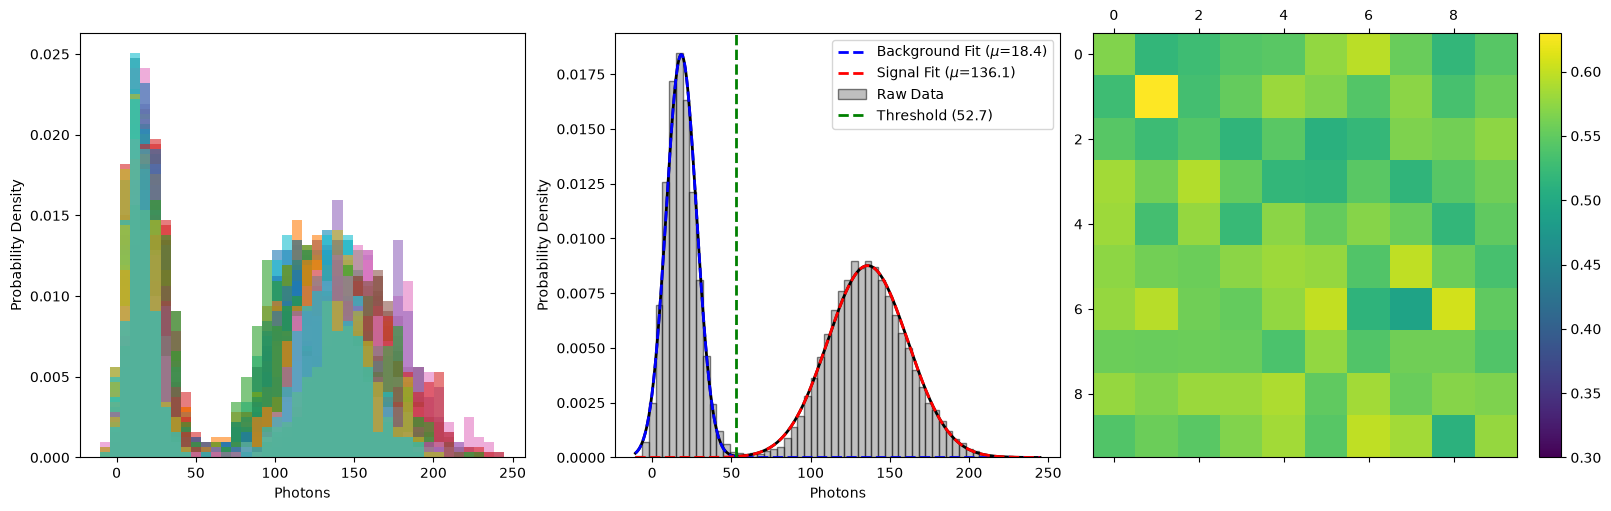

In [66]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

Trap (0, 0) Loading Probability : 56.80 %
Trap (0, 1) Loading Probability : 51.80 %
Trap (0, 2) Loading Probability : 53.00 %
Trap (0, 3) Loading Probability : 54.20 %
Trap (0, 4) Loading Probability : 54.60 %
Trap (0, 5) Loading Probability : 57.80 %
Trap (0, 6) Loading Probability : 59.80 %
Trap (0, 7) Loading Probability : 55.20 %
Trap (0, 8) Loading Probability : 52.00 %
Trap (0, 9) Loading Probability : 54.60 %
Trap (1, 0) Loading Probability : 53.20 %
Trap (1, 1) Loading Probability : 63.00 %
Trap (1, 2) Loading Probability : 52.80 %
Trap (1, 3) Loading Probability : 55.20 %
Trap (1, 4) Loading Probability : 58.00 %
Trap (1, 5) Loading Probability : 57.00 %
Trap (1, 6) Loading Probability : 54.40 %
Trap (1, 7) Loading Probability : 57.00 %
Trap (1, 8) Loading Probability : 53.40 %
Trap (1, 9) Loading Probability : 55.60 %
Trap (2, 0) Loading Probability : 54.40 %
Trap (2, 1) Loading Probability : 52.60 %
Trap (2, 2) Loading Probability : 54.20 %
Trap (2, 3) Loading Probability : 

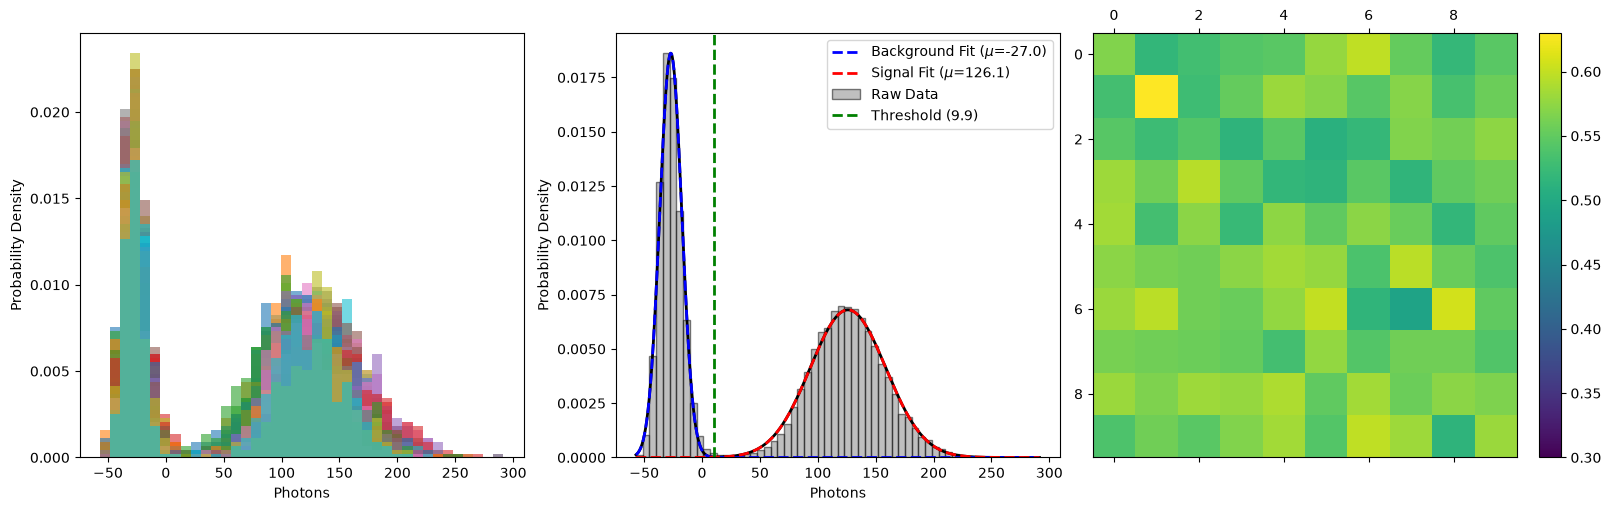

In [68]:
psf_window = 9

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

In [69]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\17Aug26"
dataset_title = "imaging_survival_5msExpo_8msTOF"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save imgs1 and imgs2 to two pickle files, one called initial, one called final, and one called photon_data
with open(os.path.join(data_dir, dataset_title, "initial_imgs.pkl"), "wb") as f:
    pickle.dump(imgs1, f)
with open(os.path.join(data_dir, dataset_title, "final_imgs.pkl"), "wb") as f:
    pickle.dump(imgs2, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Imaging survival verification for a 5 ms exposure time with a 8 ms delay. Img VCO = 2.948 and Img VVA = 1.00. 
    """)

In [77]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.
